In [6]:
import csv
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

In [7]:
with open("statistics_rep_20_kicad_rep_20_ratio_0.17.csv", "r") as file:
    csvreader = csv.DictReader(file)
    data = list(csvreader)
    print(len(data))
    print(list(data[0].keys()))
data = sorted(data, key=lambda i: float(i["comp_count"]))

120
['file', 'kicad_netlist_file', 'group_netlist_file', 'csv_file', 'code_file', 'sym_count_in_root_sheet', 'annotated_symbols_in_root_sheet', 'comp_count', 'net_count', 'average_pins_per_group', 'groups', 'nets', 'nets_with_multiple_nodes', 'csv_lines', 'kicad-cli', 'kicad_group_netlister', 'code_gen', 'netlist_to_csv', 'test_case']


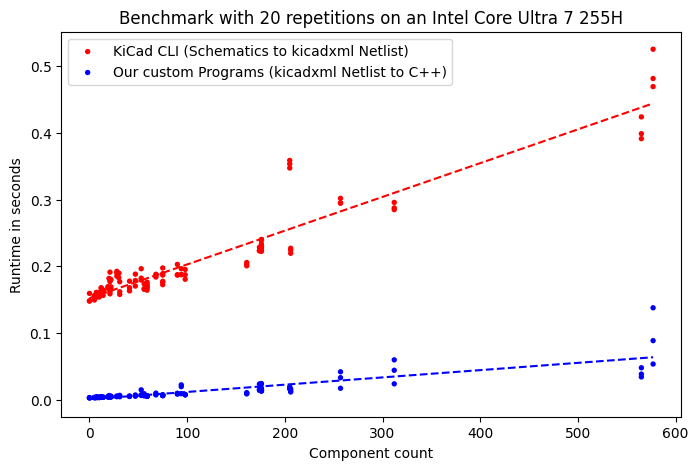

In [15]:
comp_count = np.array([float(item["comp_count"]) for item in data])
kicad_cli = np.array([float(item["kicad-cli"]) for item in data])
kicad_group_netlister = np.array([float(item["kicad_group_netlister"]) for item in data])
code_gen = np.array([float(item["code_gen"]) for item in data])
netlist_to_csv = np.array([float(item["netlist_to_csv"]) for item in data])

full_code_gen = kicad_group_netlister + code_gen

def get_line(x):
    coef = np.polyfit(comp_count, x, 1)
    return np.poly1d(coef)(comp_count)

fig, ax = plt.subplots(figsize=(8, 5))
scale = 15

full = False


ax.scatter(comp_count, kicad_cli, c="red", s=scale, label="KiCad CLI (Schematics to kicadxml Netlist)", edgecolors='none')
ax.plot(comp_count, get_line(kicad_cli), '--', color="red")

if full:
    ax.scatter(comp_count, kicad_group_netlister, c="blue", s=scale, label="kicad_group_netlister", edgecolors='none')
    ax.plot(comp_count, get_line(kicad_group_netlister), '--', color="blue")

    ax.scatter(comp_count, code_gen, c="orange", s=scale, label="code_gen", edgecolors='none')
    ax.plot(comp_count, get_line(code_gen), '--', color="orange")

    ax.scatter(comp_count, netlist_to_csv, c="green", s=scale, label="netlist_to_csv", edgecolors='none')
    ax.plot(comp_count, get_line(netlist_to_csv), '--', color="green")
else:
    ax.scatter(comp_count, full_code_gen, c="blue", s=scale, label="Our custom Programs (kicadxml Netlist to C++)", edgecolors='none')
    ax.plot(comp_count, get_line(full_code_gen), '--', color="blue")


plt.title("Benchmark with 20 repetitions on an Intel Core Ultra 7 255H")
plt.xlabel("Component count")
plt.ylabel("Runtime in seconds")
ax.legend()

plt.savefig(f"synth_results_{'full' if full else 'combined'}.svg")
plt.show()

In [9]:
np.max((kicad_cli+full_code_gen)/(kicad_cli))-1

np.float64(0.2859260821420637)

In [10]:
np.average((kicad_cli+full_code_gen)/(kicad_cli))-1

np.float64(0.04828112908854276)